*heteroTests tutorial series — [01. Detecting heteroscedasticity](01-detecting-heteroscedasticity.ipynb) · **02. Remediation** · [03. Modern & scalable diagnostics](03-modern-and-scalable.ipynb) · [04. Group-wise variance tests](04-group-wise-variance.ipynb) · [05. Time series & ARCH effects](05-time-series-arch.ipynb) · [06. Choosing a test: a power study](06-choosing-a-test.ipynb)*


# Remediating Heteroscedasticity

**Robust inference, weighted least squares, and variance-stabilising transforms**

---

Notebook 1 established that the earthquake-station model is heteroscedastic and
its OLS standard errors are, as a result, too small. Detecting the problem is
only half the job. This notebook covers the three standard families of remedy
and --- importantly --- shows *where each one provably works* and where it does
not:

| Strategy | Changes the model? | When to prefer it |
|----------|-------------------|-------------------|
| **Robust (HC) standard errors** | No | Default; you only need valid inference |
| **Weighted least squares (WLS)** | Re-weights | You can model the variance and want efficiency |
| **Variance-stabilising transform** | Yes (response scale) | Multiplicative error; interpretation on new scale is acceptable |

We use controlled simulations with a *known* variance structure to demonstrate
that WLS and transforms work as advertised, then return to the real data with
appropriate caveats.


In [1]:
library(heteroTests)
ht_set_log_level("SILENT")  # keep simulation loops quiet
library(ggplot2)
theme_set(theme_minimal(base_size = 12))
options(digits = 4)
data(quakes)
model <- lm(stations ~ mag + depth, data = quakes)
# Recap: the data are heteroscedastic (see notebook 1)
signif(performKoenkerTest(model, quakes)$p.value, 3)


Warning message:
"package 'ggplot2' was built under R version 4.5.3"


[1] 6.77e-25

## Strategy A --- Robust (HC) standard errors

The least invasive fix keeps the OLS point estimates and only replaces the
covariance estimator with a heteroscedasticity-consistent (HC) one. Nothing
about the model changes; you simply stop trusting the wrong standard errors.
This is the right default whenever your goal is valid inference rather than
efficiency.

Below we contrast the 95% confidence intervals from classical OLS with their
HC3 counterparts.


In [2]:
X <- model.matrix(model); e <- residuals(model); h <- hatvalues(model)
V_ols <- vcov(model)
V_hc3 <- solve(crossprod(X)) %*% crossprod(X, (e^2 / (1 - h)^2) * X) %*% solve(crossprod(X))
b  <- coef(model)
se_ols <- sqrt(diag(V_ols)); se_hc3 <- sqrt(diag(V_hc3))
ci <- data.frame(
  term      = names(b),
  estimate  = round(b, 3),
  OLS_lo    = round(b - 1.96 * se_ols, 3), OLS_hi = round(b + 1.96 * se_ols, 3),
  HC3_lo    = round(b - 1.96 * se_hc3, 3), HC3_hi = round(b + 1.96 * se_hc3, 3),
  width_ratio = round(se_hc3 / se_ols, 2), row.names = NULL)
ci


term,estimate,OLS_lo,OLS_hi,HC3_lo,HC3_hi,width_ratio
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-192.043,-200.53,-183.553,-203.05,-181.036,1.30
mag,47.909,46.14,49.676,45.53,50.284,1.34
depth,0.013,0.01,0.016,0.01,0.017,1.03


The HC3 intervals are noticeably wider for `mag`. Widening is
a symptom, not a test. To decide whether the variance really is non-constant,
use a score test. Koenker's studentised version is the one to reach for here,
because it does not lean on normal errors:


In [3]:
performKoenkerTest(model, quakes)



	Koenker studentized Breusch-Pagan test

data:  stations ~ mag + depth
X-squared = 111, df = 2, p-value <2e-16


## Strategy B --- Weighted least squares

If $\operatorname{Var}(\varepsilon_i)=\sigma^2 / w_i$ is known up to a constant,
weighting each observation by $w_i$ recovers the best linear unbiased estimator:
it is both correctly calibrated *and* more efficient than OLS. The diagnostic
for a WLS fit is run on the **weighted residuals** $\sqrt{w_i}\,e_i$, not the raw
ones.

### Demonstration with a known variance

We simulate $y = 2 + 1.5x + \varepsilon$ with $\operatorname{sd}(\varepsilon_i)=0.5x_i$,
so the correct weights are $w_i = 1/(0.5x_i)^2$.


In [4]:
set.seed(42)
n <- 400; x <- runif(n, 1, 5); sd_true <- 0.5 * x
y <- 2 + 1.5 * x + rnorm(n, sd = sd_true)
d <- data.frame(y, x, w = 1 / sd_true^2)
m_ols <- lm(y ~ x, data = d)
m_wls <- lm(y ~ x, data = d, weights = w)

# Diagnose the WLS fit on its WEIGHTED residuals (OLS on weight-scaled data)
sw <- sqrt(d$w)
dt <- data.frame(ys = sw * d$y, c0 = sw, xs = sw * d$x)
m_weighted_check <- lm(ys ~ 0 + c0 + xs, data = dt)

data.frame(
  fit      = c("OLS (raw residuals)", "WLS (weighted residuals)"),
  koenker_p = signif(c(performKoenkerTest(m_ols, d)$p.value,
                       performKoenkerTest(m_weighted_check, dt)$p.value), 3),
  se_slope  = round(c(sqrt(vcov(m_ols)[2, 2]), sqrt(vcov(m_wls)[2, 2])), 4))


fit,koenker_p,se_slope
<chr>,<dbl>,<dbl>
OLS (raw residuals),1.66e-14,0.0689
WLS (weighted residuals),9.67e-01,0.0566


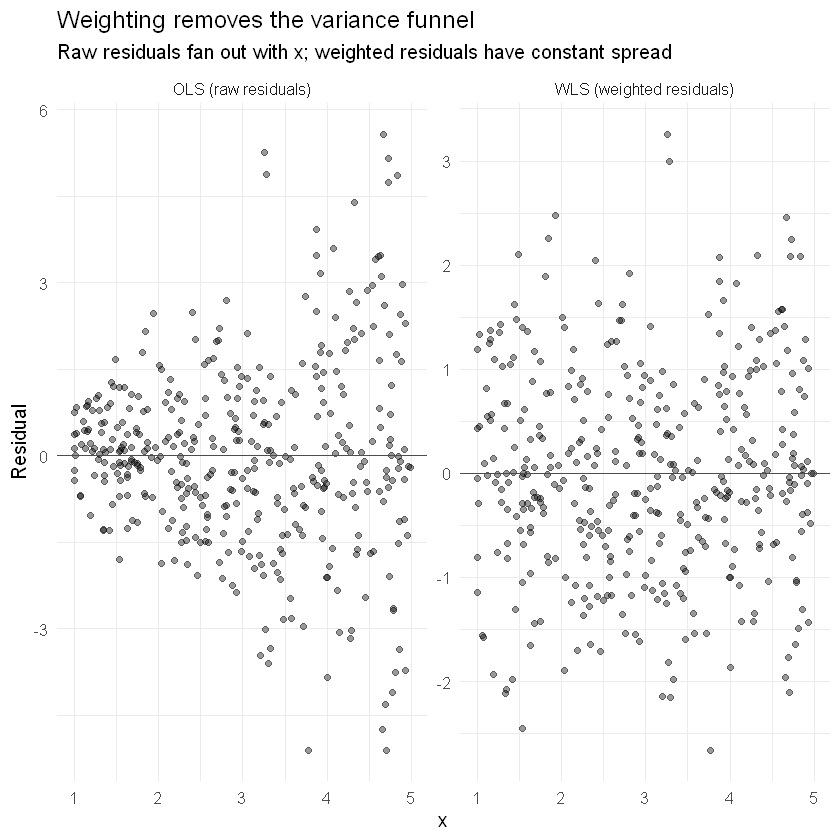

In [5]:
# Before/after: the funnel in the OLS residuals is gone after weighting
resid_df <- rbind(
  data.frame(x = d$x, r = residuals(m_ols),           fit = "OLS (raw residuals)"),
  data.frame(x = d$x, r = residuals(m_weighted_check), fit = "WLS (weighted residuals)"))
ggplot(resid_df, aes(x, r)) +
  geom_point(alpha = 0.4) +
  geom_hline(yintercept = 0, colour = "firebrick") +
  facet_wrap(~fit, scales = "free_y") +
  labs(x = "x", y = "Residual",
       title = "Weighting removes the variance funnel",
       subtitle = "Raw residuals fan out with x; weighted residuals have constant spread")


With the correct weights, WLS does two things at once: the weighted residuals
are now homoscedastic (Koenker $p \approx 0.97$, up from $\approx 10^{-14}$),
**and** the slope standard error shrinks --- a genuine efficiency gain, not just
a recalibration.

### On real data: feasible WLS

Real weights are unknown and must be estimated from a variance model, which is
where WLS becomes an art. A common recipe regresses $\log e_i^2$ on the fitted
values and uses the predicted variance to form weights:


In [6]:
v_model <- lm(log(residuals(model)^2) ~ fitted(model))
w_hat   <- 1 / exp(fitted(v_model))
wls_q  <- lm(stations ~ mag + depth, data = quakes, weights = w_hat)

# Variance of residuals across thirds of the fitted range, raw vs weighted
third <- cut(fitted(model), 3, labels = c("low", "mid", "high"))
rbind(
  OLS_raw_resid_var      = round(tapply(residuals(model)^2, third, mean), 1),
  WLS_weighted_resid_var = round(tapply((residuals(wls_q) * sqrt(w_hat))^2,
                                        cut(fitted(wls_q), 3), mean), 2))


,low,mid,high
OLS_raw_resid_var,80.30,196.90,526.40
WLS_weighted_resid_var,2.82,4.15,8.04


Feasible WLS markedly flattens the residual-variance profile across the fitted
range, though it does not perfectly remove the pattern --- the estimated
variance model is only approximate. This is the honest reality: WLS buys
efficiency *when you can model the variance well*, and robust standard errors
remain the safer default when you cannot.


## Strategy C --- Variance-stabilising transforms

When the error is multiplicative --- $y = e^{X\beta}\cdot\eta$ with
$\operatorname{sd}(\eta)$ scaling with the level --- a log transform stabilises
the variance and often linearises the relationship at the same time. We show
this on a simulation where the mechanism is known.


In [7]:
set.seed(7)
x2 <- runif(400, 1, 5)
y2 <- exp(1 + 0.3 * x2 + rnorm(400, sd = 0.4))   # multiplicative error
d2 <- data.frame(y = y2, x = x2)
data.frame(
  model     = c("y ~ x (level)", "log(y) ~ x"),
  koenker_p = signif(c(performKoenkerTest(lm(y ~ x, d2), d2)$p.value,
                       performKoenkerTest(lm(log(y) ~ x, d2), d2)$p.value), 3))


Warning message:
"Residual outliers detected at rows 363 (|z| > 5). Inspect leverage before running Koenker."


Warning message:
"Residual outliers detected at rows 363 (|z| > 5). Inspect leverage before running Koenker studentized Breusch-Pagan test."


model,koenker_p
<chr>,<dbl>
y ~ x (level),2.21e-07
log(y) ~ x,1.92e-01


The log model is comfortably homoscedastic ($p \approx 0.19$) where the level
model was not ($p \approx 10^{-7}$). The caveat is interpretive: coefficients
now describe the response on the log scale. A transform is appropriate only when
that change of scale is acceptable for the question at hand.


## Letting the package advise

`generateHeteroRecommendations()` profiles the data, runs an appropriate panel
of diagnostics, and prints structured guidance --- useful as a starting point or
for non-specialist collaborators.


In [8]:
generateHeteroRecommendations(model, quakes)


Heteroscedasticity Recommendation Overview
--------------------------------------------------
Observations: 1000 | Variables: 5
Sample size category: large
Missingness: none (0.0%)

Key recommendations:
- breusch_pagan: Baseline regression-based heteroscedasticity check.
- quantile_regression: Variables long, mag, stations show strong skewness; quantile slope comparisons provide a complementary distributional check.
- spatial_hetero: Spatial diagnostic for geographic residual-scale structure.
- white: Detects general forms of non-constant variance.
- wild_bootstrap: Bootstrap-based inference can complement spatial diagnostics when its assumptions are appropriate.

Summary:
2 diagnostics indicate heteroscedasticity; remediation is recommended. 
Multiple diagnostics highlight variance instability. 

Narrative excerpt:
Heteroscedasticity Diagnostic Recommendation Report
Observations: 1000; Variables: 5
Sample size category: large
Missingness level: none (0.0% overall)
Response variable: s

## Decision guide

- **Need valid inference, nothing more?** Use HC (robust) standard errors. They
  are always valid under heteroscedasticity and require no modelling choices.
- **Can you model the variance, and want efficiency?** Use WLS, and diagnose it
  on the *weighted* residuals. Verify the weights with a residual-variance
  profile before trusting the gain.
- **Is the error multiplicative and a scale change acceptable?** A log (or
  Box--Cox) transform can remove the problem at its source.
- **In doubt?** Robust standard errors are the safe default; the other two are
  efficiency or modelling refinements layered on top.

Notebook 3 turns to the modern, resampling-based and scalable diagnostics for
settings where the classical asymptotics are unreliable or the data do not fit
in memory.

---


In [9]:
sessionInfo()


R version 4.5.1 (2025-06-13 ucrt)
Platform: x86_64-w64-mingw32/x64
Running under: Windows 11 x64 (build 26200)

Matrix products: default
  LAPACK version 3.12.1

locale:
[1] LC_COLLATE=English_United Kingdom.utf8 
[2] LC_CTYPE=English_United Kingdom.utf8   
[3] LC_MONETARY=English_United Kingdom.utf8
[4] LC_NUMERIC=C                           
[5] LC_TIME=English_United Kingdom.utf8    

time zone: Europe/Lisbon
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] ggplot2_4.0.2     heteroTests_0.8.1

loaded via a namespace (and not attached):
 [1] crayon_1.5.3       vctrs_0.7.2        cli_3.6.5          rlang_1.1.7       
 [5] generics_0.1.4     S7_0.2.0           textshaping_1.0.4  jsonlite_2.0.0    
 [9] labeling_0.4.3     glue_1.8.0         htmltools_0.5.8.1  IRdisplay_1.1     
[13] IRkernel_1.3.2     ragg_1.5.0         scales_1.4.0       grid_4.5.1        
[17] tibble_3.3.1       eva